In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x ** 2 + x + 2 + np.random.rand(m,1)

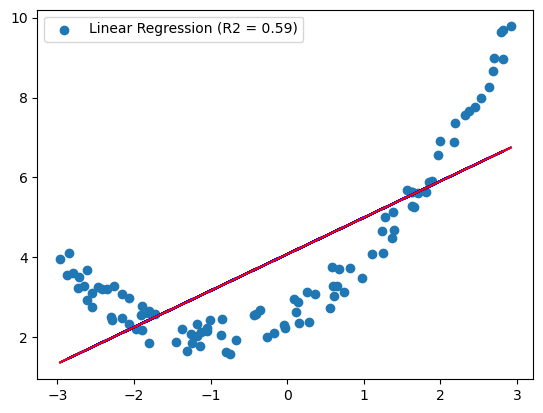

0.5884639595731203


In [ ]:
# 1. x, y를 그려서 데이터 분포 확인
# 2. 모델 적용, 선형회귀 적용 np.linspace( x.min(), x.max(), 100 ) => y는 예측값을 구해서 plot으로 추세선
# 3. RandomForestRegression 적용해서 모델에 적용하고 시각화
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)
plt.scatter(x,y)
plt.plot(x, y_pred, color='b')
plt.plot(np.linspace(x.min(), x.max(), 100), np.linspace(y_pred.min(), y_pred.max(), 100), color='red')
plt.legend([f"Linear Regression (R2 = {lr.score(x,y):.2f})"])
plt.show()
print(lr.score(x,y))


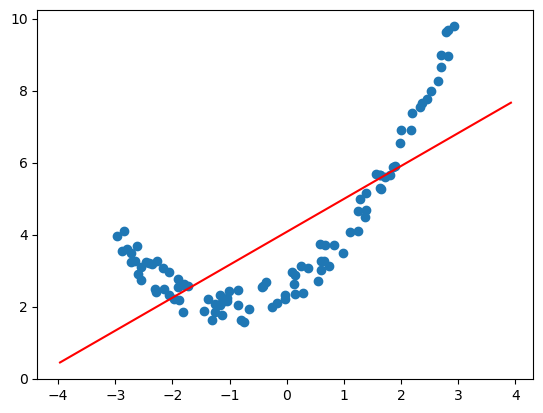

In [38]:
# 1. x, y를 그려서 데이터 분포 확인
# 2. 모델 적용, 선형회귀 적용 np.linspace( x.min(), x.max(), 100 ) => y는 예측값을 구해서 plot으로 추세선
# 3. RandomForestRegression 적용해서 모델에 적용하고 시각화
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()
lr.fit(x,y)
new_x = np.linspace(x.min() -1, x.max() + 1, 100).reshape(-1,1)
y_pred = lr.predict(new_x)
plt.scatter(x,y)
plt.plot(new_x, y_pred, color='r')
plt.show()



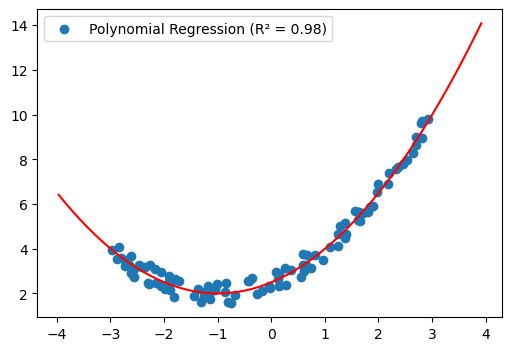

In [46]:
p_x = np.hstack([x**2, x])
lin_reg = LinearRegression()
lin_reg.fit(p_x,y)
y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

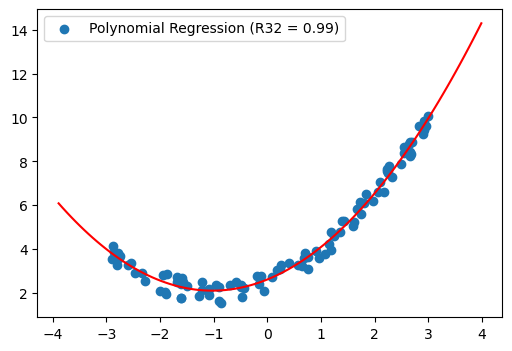

In [86]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_x = poly_features.fit_transform(x)
lin_reg.fit(poly_x, y)
new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
ploy_new_x = poly_features.transform(new_x)
y_pred = lin_reg.predict(ploy_new_x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='r')
plt.legend([f"Polynomial Regression (R32 = {lin_reg.score(poly_x, y):.2f})"])
plt.show()

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


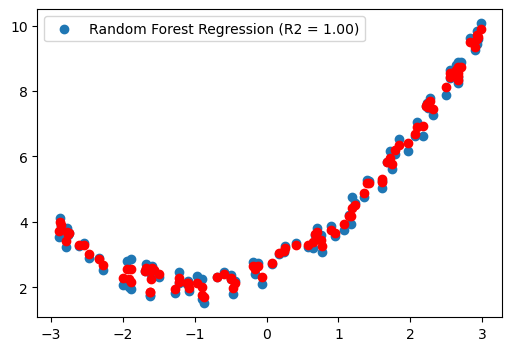

In [84]:
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x ** 2 + x + 2 + np.random.rand(m,1)
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(x, y)
y_predict = forest_reg.predict(x)
fig, ax = plt.subplots(figsize = (6,4))
ax.scatter(x,y)
ax.scatter(x, y_predict, color='r')
plt.legend([f'Random Forest Regression (R2 = {forest_reg.score(x, y):.2f})'])
plt.show()

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


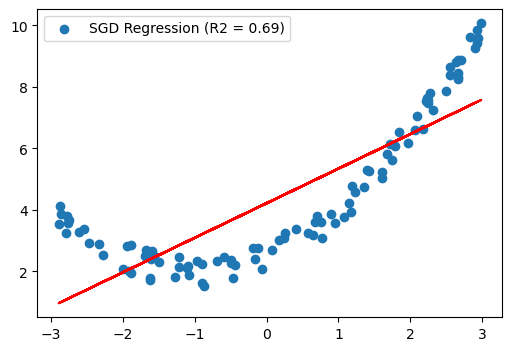

In [ ]:
# 확률적 경사 하강법 모델
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor()
sgd.fit(x, y)

y_pred = sgd.predict(x)

fig, ax = plt.subplots(figsize = (6,4))
ax.scatter(x,y)
ax.plot(x, y_pred, color='r')
plt.legend([f'SGD Regression (R2 = {sgd.score(x, y):.2f})'])
plt.show()


c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


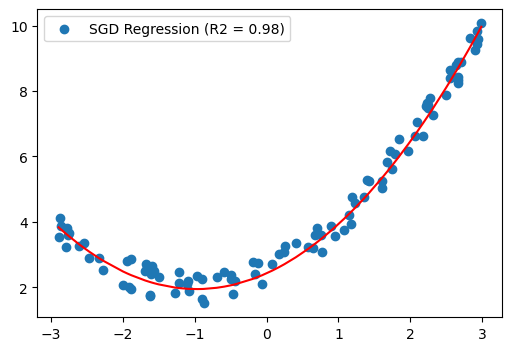

In [104]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

sgd = SGDRegressor()
sgd.fit(x_poly, y)
y_pred = sgd.predict(x_poly)

sorted_idx = x[:,0].argsort()
x_sorted = x[sorted_idx]
y_sorted = y_pred[sorted_idx]


fig, ax = plt.subplots(figsize = (6,4))
ax.scatter(x,y)
ax.plot(x_sorted, y_sorted, color='r')
plt.legend([f'SGD Regression (R2 = {sgd.score(x_poly, y):.2f})'])
plt.show()

In [ ]:
# 과적합(과대적합, 과소적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

#샘플 수 적게
n_samples = 20
# feature 수 많게 -> 과적합 유도
n_features = 100 # 컬럼 수, x의 수
x = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features) # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하게 설정
true_coef[:5] = [10, -7, 5, 3, -2] # 실제로 앞의 5개만 y에 영향을 줌 나머지 95개는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성 y = 10x1 + (-7x2) + 5x3 +
y = x @ true_coef + np.random.rand(n_samples) * 5 # 정규분포 노이즈, 표준편차 5 => 큰 노이즈

# 일반 선형회귀
from sklearn.model_selection import train_test_split
# 학습
# 결정계수 .. score 학습용 데이터, 테스트 데이터
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
print( lr.score(x_train, y_train) )
print( lr.score(x_test, y_test) )


1.0
0.3977376279359226


array([ 1.89028079, -1.74067593,  0.78064284,  0.49170558,  0.01888018,
       -0.0569318 ,  0.66037672, -1.56270826, -0.20072715,  0.70329681,
       -0.29049792,  0.45751379,  0.66105278, -0.4574752 ,  0.31284073,
       -0.95340572,  0.05042448,  0.13132594, -0.31272258,  0.21470125,
       -0.46598828,  0.58114951,  0.98447039, -0.49361622,  0.55644833,
        0.56214622, -0.28253578, -0.36941439,  0.5345359 ,  0.63249185,
       -0.97664337,  0.21053386,  0.14854196, -0.10437393, -0.21585459,
        0.33409899,  0.51129438, -0.98685368, -0.27004331,  0.0751822 ,
        0.06453996, -0.07070684,  0.05260146, -0.10326932, -0.07509616,
        0.23480598,  0.54919225, -0.58169807,  0.86850017, -0.2665812 ,
       -0.38004673,  0.21839   , -0.54407252, -0.92643731,  1.14352664,
        0.72681483, -0.26577643,  0.67787643,  0.95903376, -0.30079293,
       -0.97904803,  0.4358332 , -0.03415305,  0.01924686, -0.40783752,
        0.18067863,  0.25619905,  0.17647153,  0.15939104,  0.45

In [ ]:
# 모델이 노이즈까지 학습
# 계수(가중치)가 비정상적으로 커짐
# 해결 방안 .. 규제(Regulization)
# Ridge (L2)
    # loss = MSE + alpha*sum(가중치**2) => 계수(가중치) 전체적으로 작게 만듬, 모든 feature 유지 => 안정적
    # 입력 스케일에 민감하기 때문에 표준화 필요
# Rasso (L1)
    # loss = MSE + alpha*sum(|가중치|) => 일부 계수(가중치)를 0으로 만듬, 자동 feature selection

from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=30)
ridge.fit(x_train, y_train)
ridge.score(x_train, y_train) , ridge.score(x_test, y_test)



(0.9432168631266318, 0.37901009934554386)

In [170]:
from sklearn.linear_model import Ridge, Lasso
lasso = Lasso(alpha=3)
lasso.fit(x_train, y_train)
lasso.score(x_train, y_train) , lasso.score(x_test, y_test)


(0.8846808260769442, 0.47237087932487654)

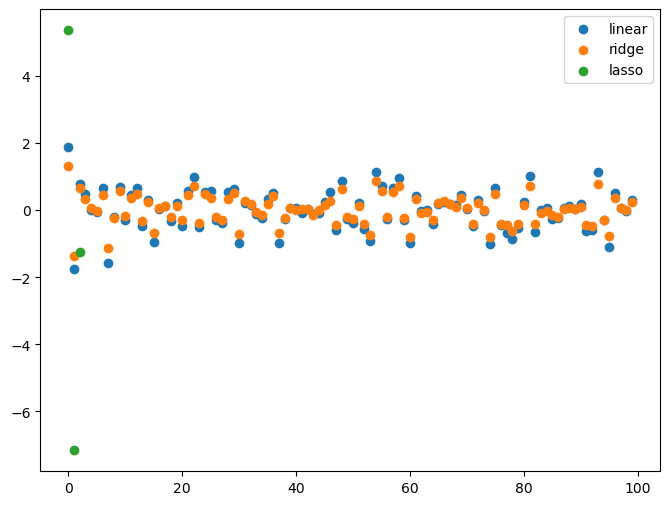

In [ ]:
# 계수비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(lr.coef_[lr.coef_ != 0])), lr.coef_[lr.coef_ != 0], label='linear')
ax.scatter(np.arange(len(ridge.coef_[ridge.coef_ != 0])), ridge.coef_[ridge.coef_ != 0], label='ridge')
ax.scatter(np.arange(len(lasso.coef_[lasso.coef_ != 0])), lasso.coef_[lasso.coef_ != 0], label='lasso')
plt.legend()
plt.show()

# linear 개수 많음(과적합) Ridge 전체적으로 작아짐 Lasso 일부 계수는 0으로 만들어 버림

In [172]:
# 릿지와 라쏘의 장점을 모두 갖춘 엘라스틱넛(ElasticNet)
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 1, l1_ratio=0.5) # l1_ratio = 0.5 Ridge와 Lasso의 비율

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np

# 2차 방정식 데이터셋
np.random.seed(42)
m = 100
x = 6 * np.random.rand(m,1) -3
y = 0.5 * x**2 + x + 2 +np.random.rand(m,1) # w1x1**2 + w2xw

x_train, y_train = x[:m//2], y[:, m//2, 0]
x_valid, y_valid = x[m//2:], y[m//2:, 0]

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=90, include_bias=False)),
    ('scale', StandardScaler())
])

x_train_prep = pipeline.fit_transform(x_train)
x_valid_prep = pipeline.transform(x_valid)

# 규제가 없고 학습률이 작은 모델
sgd_reg = SGDRegressor(penalty=None, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []

from copy import deepcopy

for epoch in range(n_epochs):
    sgd_reg.partial_fit(x_train_prep, y_train)
    # fit => 전체데이터 학습
    # partial_fit => 데이터를 조금씩 가져와서 학습
    y_valid_predict = sgd_reg.predict(x_valid_prep)
    val_error = mean_squared_error(y_valid,y_valid_predict)
    val_errors.append(val_error)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_errors
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(x_train_prep)
    train_error = mean_squared_error(y_train, y_train_predict)
    val_errors.append(train_error)
    






IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed